In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

daily = pd.read_parquet(project_root / "data" / "processed" / "daily_metrics.parquet")
daily['date'] = pd.to_datetime(daily['date'])

print("Data loaded. Shape:", daily.shape)
display(daily.head())

Data loaded. Shape: (102, 13)


,date,Account,daily_pnl,win_rate,trade_count,avg_trade_size_usd,avg_leverage,long_short_ratio,max_daily_drawdown,classification,leverage_segment,frequency_segment,consistency_segment
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,3,159.000000,1.0,3.000000,0.000000,Greed,Low (0-5x),Low freq,Low win rate (<40%)
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,2,23066.935000,1.0,2.000000,0.000000,Greed,Low (0-5x),Low freq,Low win rate (<40%)
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,0.275168,1043,11034.799511,1.0,0.882671,-892.507908,Greed,Low (0-5x),High freq,Low win rate (<40%)
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,0.333333,27,3048.594444,1.0,0.173913,-5564.016140,Extreme Greed,Low (0-5x),Low freq,Low win rate (<40%)
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000,0.000000,88,1136.312727,1.0,88.000000,0.000000,Extreme Greed,Low (0-5x),Low freq,Medium win rate (40-60%)


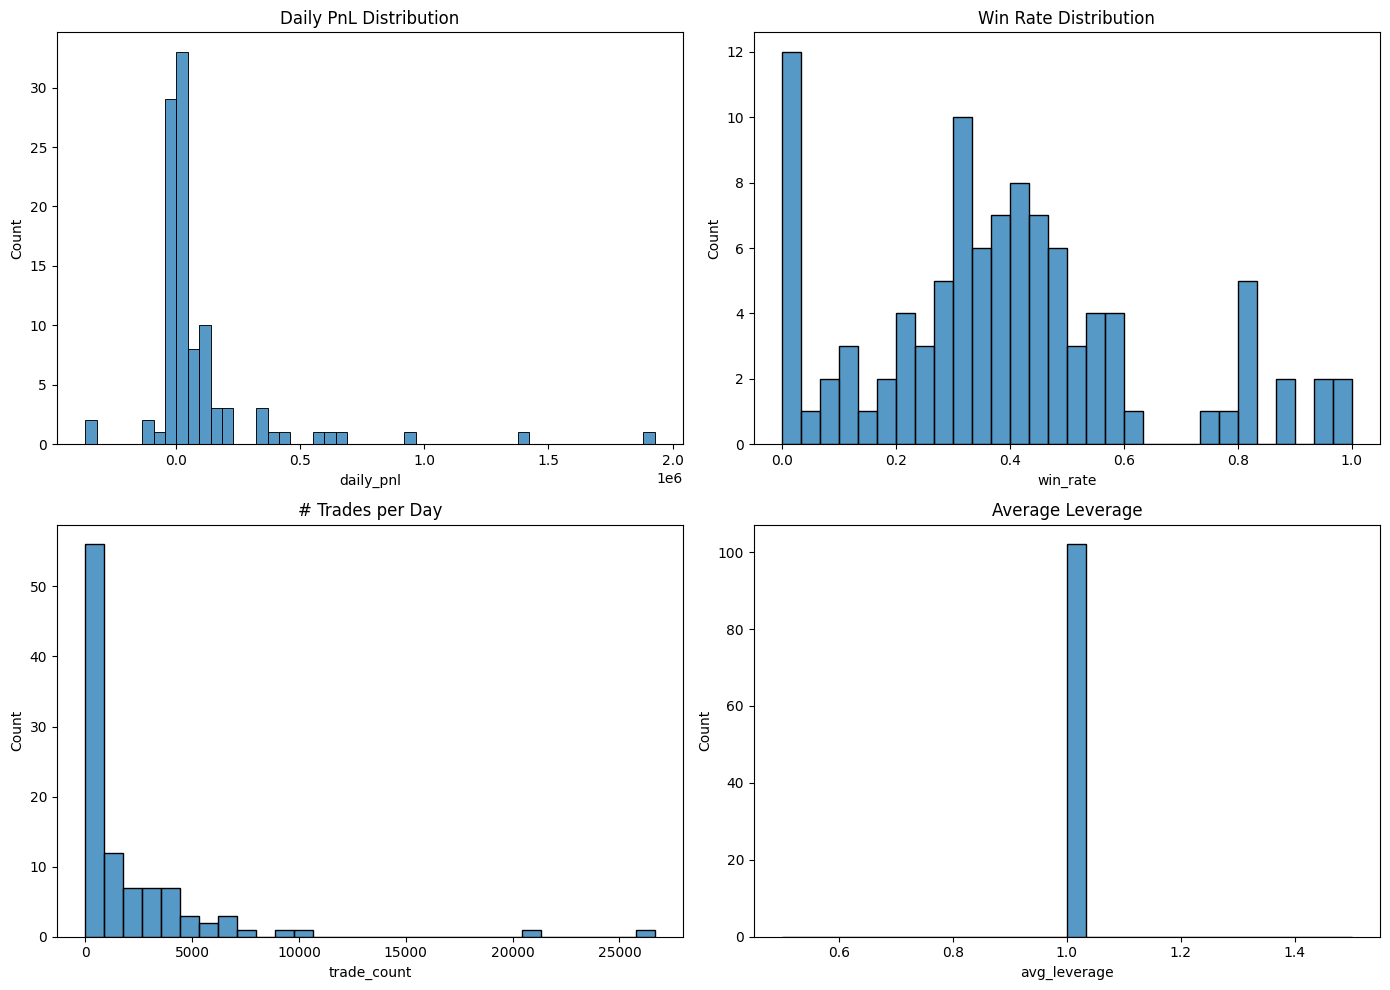

In [2]:
# Distribution of key metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(daily['daily_pnl'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Daily PnL Distribution')
sns.histplot(daily['win_rate'], bins=30, ax=axes[0,1])
axes[0,1].set_title('Win Rate Distribution')
sns.histplot(daily['trade_count'], bins=30, ax=axes[1,0])
axes[1,0].set_title('# Trades per Day')
sns.histplot(daily['avg_leverage'], bins=30, ax=axes[1,1])
axes[1,1].set_title('Average Leverage')
plt.tight_layout()
plt.show()

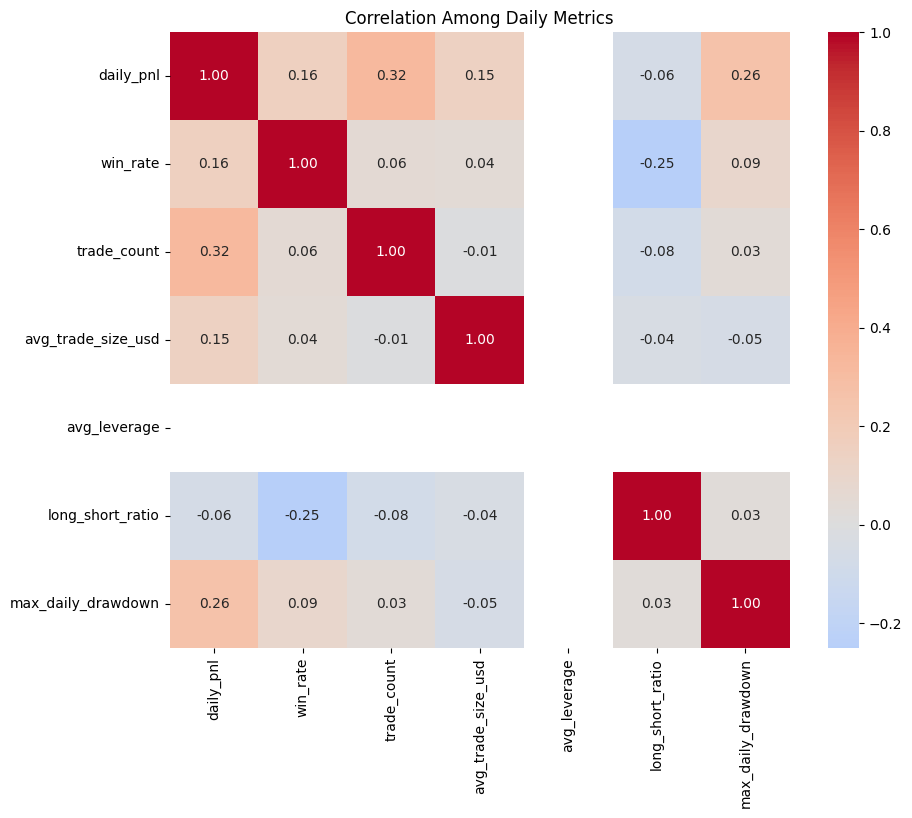

In [3]:
# Correlation heatmap
cols = ['daily_pnl', 'win_rate', 'trade_count', 'avg_trade_size_usd', 'avg_leverage', 'long_short_ratio', 'max_daily_drawdown']
plt.figure(figsize=(10, 8))
sns.heatmap(daily[cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Among Daily Metrics')
plt.show()

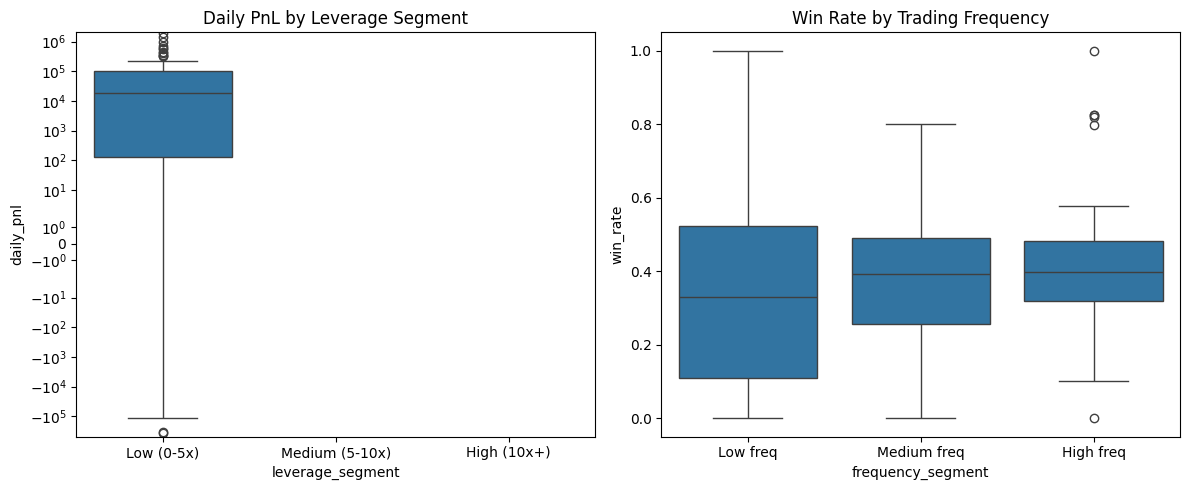

In [4]:
# Leverage segment vs PnL
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.boxplot(data=daily, x='leverage_segment', y='daily_pnl')
plt.title('Daily PnL by Leverage Segment')
plt.yscale('symlog')

plt.subplot(1,2,2)
sns.boxplot(data=daily, x='frequency_segment', y='win_rate')
plt.title('Win Rate by Trading Frequency')
plt.tight_layout()
plt.show()

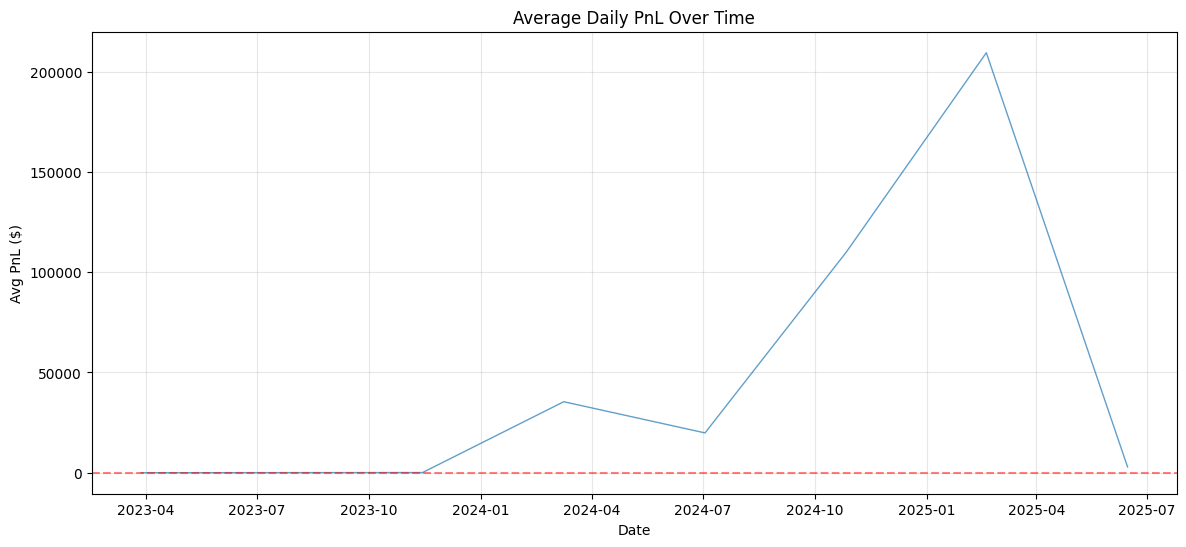

In [5]:
# Time series of average daily PnL
daily_avg = daily.groupby('date')['daily_pnl'].mean().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(daily_avg['date'], daily_avg['daily_pnl'], linewidth=1, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Average Daily PnL Over Time')
plt.xlabel('Date')
plt.ylabel('Avg PnL ($)')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Segment profiles (summary table)
segment_summary = daily.groupby('leverage_segment').agg(
    count=('Account', 'count'),
    avg_pnl=('daily_pnl', 'mean'),
    median_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades=('trade_count', 'mean')
).round(2)
display(segment_summary)

C:\Users\naval\AppData\Local\Temp\ipykernel_11756\2854990958.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = daily.groupby('leverage_segment').agg(


,count,avg_pnl,median_pnl,avg_win_rate,avg_trades
leverage_segment,,,,,
Low (0-5x),102,100950.58,18485.26,0.39,2070.82
Medium (5-10x),0,NaN,NaN,NaN,NaN
High (10x+),0,NaN,NaN,NaN,NaN


C:\Users\naval\AppData\Local\Temp\ipykernel_11756\4149265678.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=daily, x='leverage_segment', y='daily_pnl', scale='width')


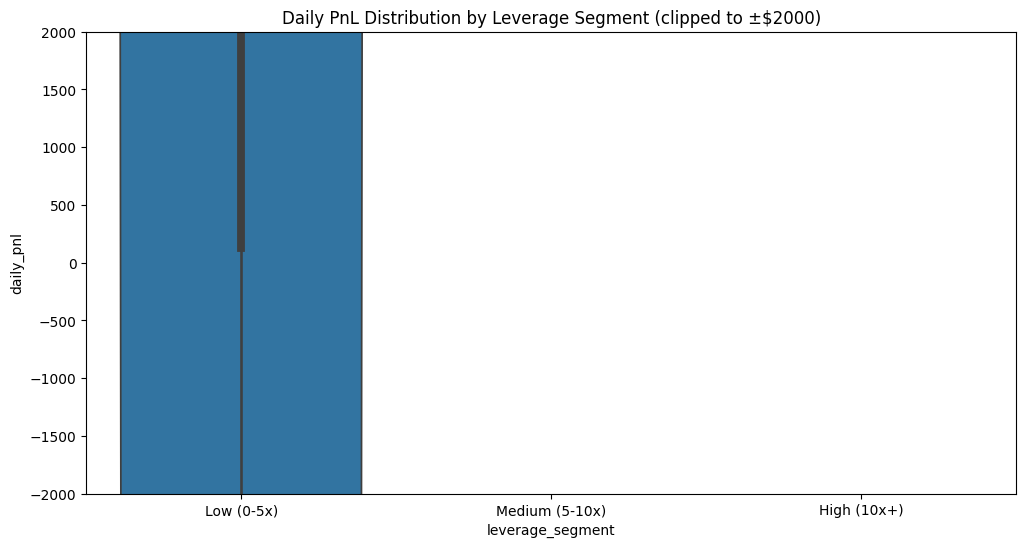

In [7]:
# PnL distribution per segment (violin plot)
plt.figure(figsize=(12,6))
sns.violinplot(data=daily, x='leverage_segment', y='daily_pnl', scale='width')
plt.ylim(-2000, 2000)
plt.title('Daily PnL Distribution by Leverage Segment (clipped to ±$2000)')
plt.show()